# Point-Source Contribution — Playground #7

Two players can finish on the *same* points and be completely different assets. One midfielder banks 80% of his haul from goals and assists (matchup-sensitive, boom-or-bust); another grinds out appearances, bonus, and the new **defensive-contribution** points (a near-guaranteed floor). This notebook decomposes each top player's season into **where the points came from**.

Spec: [brainstorming/14](../../brainstorming/14-point-source-contribution.md).

**CS problem:** *additive attribution*. We decompose one scalar (`total_points`) into a fixed set of mutually-exclusive buckets, then normalise each to a **share of the total** — the same shape as a stacked composition (parts that sum to a whole).

**The honest twist:** the data gives us raw *counts* (`goals_scored`, `assists`, …), not per-source points. So we **rebuild** every bucket from the FPL 2025/26 scoring rules and **reconcile** the reconstructed total against the recorded `total_points`. The residual is the built-in error bar — a decomposition you can *audit*.

## Config — edit me

In [20]:
SEASON = "2025-26"
BASE   = f"https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{SEASON}"
MERGED_URL = f"{BASE}/gws/merged_gw.csv"

# Analysis universe: top-K per position by TOTAL points. K/L/M/N here.
TOP_PER_POS = {"GK": 6, "DEF": 15, "MID": 15, "FWD": 9}   # 30 players

# --- FPL 2025/26 scoring rules (position-aware) ---
GOAL_PTS = {"GK": 6, "DEF": 6, "MID": 5, "FWD": 4}
CS_PTS   = {"GK": 4, "DEF": 4, "MID": 1, "FWD": 0}   # clean sheet only counts on a 60+ min GW
ASSIST_PTS = 3
# Defensive contribution (new for 2025/26): +2 per GW at/above the position threshold.
# DEF qualify at >=10 (CBI); MID/FWD at >=12 (CBIT/CBIR). GK have no DC category.
DC_THRESH = {"DEF": 10, "MID": 12, "FWD": 12, "GK": 10**9}
DC_PTS = 2
# Deductions & GK bonuses
SAVE_PTS_PER = 1   # +1 per 3 saves (GK)
SAVES_PER_PT = 3
PEN_SAVE_PTS = 5
PEN_MISS_PTS = -2
YELLOW_PTS   = -1
RED_PTS      = -3
OWN_GOAL_PTS = -2
GC_PER       = 2   # GK/DEF: -1 per 2 goals conceded

## Fetch

In [21]:
import io, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_csv(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    return pd.read_csv(io.BytesIO(urllib.request.urlopen(req, timeout=60).read()))

gw = read_csv(MERGED_URL)
print(f"{len(gw):,} player-GW rows | {gw['name'].nunique()} players | GWs {gw['round'].min()}–{gw['round'].max()}")

29,757 player-GW rows | 841 players | GWs 1–38


## Reconstruct point sources (per GW) + reconciliation

We score each **player-GW** row from its raw counts, because most rules use per-match thresholds and floors that do **not** survive season-summing (appearance tiers, `saves // 3`, `goals_conceded // 2`, the 60-min clean-sheet gate, the DC threshold). Then we sum reconstructed points and check them against `total_points`.

In [22]:
pos = gw["position"]
by  = lambda d: pos.map(d).fillna(0).astype(float)

# --- positive buckets ---
appearance   = np.where(gw["minutes"] >= 60, 2, np.where(gw["minutes"] > 0, 1, 0))
goals        = gw["goals_scored"] * by(GOAL_PTS)
assists      = gw["assists"] * ASSIST_PTS
clean_sheets = np.where(gw["minutes"] >= 60, gw["clean_sheets"] * by(CS_PTS), 0.0)
def_contrib  = np.where(gw["defensive_contribution"] >= pos.map(DC_THRESH).fillna(10**9), DC_PTS, 0)
# def_contrib  = 0
gk_pts       = (gw["saves"] // SAVES_PER_PT) * SAVE_PTS_PER + gw["penalties_saved"] * PEN_SAVE_PTS
bonus        = gw["bonus"].astype(float)

# --- deductions (negative) ---
gc_mask     = pos.isin(["GK", "DEF"])
goals_conc  = np.where(gc_mask, -(gw["goals_conceded"] // GC_PER), 0)
deductions  = (goals_conc
               + gw["penalties_missed"] * PEN_MISS_PTS
               + gw["yellow_cards"] * YELLOW_PTS
               + gw["red_cards"] * RED_PTS
               + gw["own_goals"] * OWN_GOAL_PTS)

BUCKETS = ["appearance", "goals", "assists", "clean_sheets", "def_contrib", "gk_pts", "bonus", "deductions"]
for name, col in zip(BUCKETS,
                     [appearance, goals, assists, clean_sheets, def_contrib, gk_pts, bonus, deductions]):
    gw[name] = np.asarray(col, dtype=float)

gw["recon"] = gw[BUCKETS].sum(axis=1)
gw["resid"] = gw["total_points"] - gw["recon"]

bad = int((gw["resid"] != 0).sum())
print(f"reconciliation: {bad} / {len(gw):,} rows with non-zero residual | "
      f"abs residual sum = {gw['resid'].abs().sum():.0f} of {gw['total_points'].sum():,.0f} total pts")
assert bad == 0, "scoring model does not reconcile — investigate before trusting the split"
print("✓ every bucket reconstructed exactly — the decomposition is lossless")

reconciliation: 0 / 29,757 rows with non-zero residual | abs residual sum = 0 of 34,409 total pts
✓ every bucket reconstructed exactly — the decomposition is lossless


## Aggregate to season totals per player

In [23]:
agg = {b: "sum" for b in BUCKETS}
agg.update({"total_points": "sum", "minutes": "sum", "position": "first"})
season = gw.groupby("name").agg(agg).reset_index()

# Team label: most-frequent team abbreviation across the player's GW rows.
team_of = gw.groupby("name")["team"].agg(lambda s: s.mode().iloc[0])
season["team"] = season["name"].map(team_of)

season = season[season["total_points"] > 0].copy()
print(f"{len(season)} players with a positive season total")
season.sort_values("total_points", ascending=False).head()

536 players with a positive season total


,name,appearance,goals,assists,clean_sheets,def_contrib,gk_pts,bonus,deductions,total_points,minutes,position,team
223,Erling Haaland,68.0,108.0,24.0,0.0,0.0,0.0,43.0,-4.0,239,2953,FWD,Man City
105,Bruno Borges Fernandes,69.0,45.0,72.0,7.0,10.0,0.0,41.0,-9.0,235,3065,MID,Man Utd
260,Gabriel dos Santos Magalhães,62.0,18.0,15.0,72.0,22.0,0.0,30.0,-10.0,209,2750,DEF,Arsenal
56,Antoine Semenyo,72.0,85.0,18.0,12.0,6.0,0.0,18.0,-9.0,202,3200,MID,Bournemouth
590,Morgan Gibbs-White,72.0,75.0,12.0,10.0,2.0,0.0,18.0,-1.0,188,3101,MID,Nott'm Forest


## Select the universe — top-K per position

In [24]:
picks = []
for p, k in TOP_PER_POS.items():
    picks.append(season[season["position"] == p]
                 .sort_values("total_points", ascending=False)
                 .head(k))
uni = pd.concat(picks, ignore_index=True)
order = {"GK": 0, "DEF": 1, "MID": 2, "FWD": 3}
uni = uni.sort_values(["position", "total_points"],
                      key=lambda s: s.map(order) if s.name == "position" else s,
                      ascending=[True, False]).reset_index(drop=True)
print(f"{len(uni)} players:",
      ", ".join(f"{p}×{TOP_PER_POS[p]}" for p in ["GK", "DEF", "MID", "FWD"]))
uni[["name", "position", "team", "total_points"]]

45 players: GK×6, DEF×15, MID×15, FWD×9


,name,position,team,total_points
0,David Raya Martín,GK,Arsenal,162
1,Caoimhín Kelleher,GK,Brentford,143
2,Robin Roefs,GK,Sunderland,136
3,Jordan Pickford,GK,Everton,135
4,Gianluigi Donnarumma,GK,Man City,135
5,Dean Henderson,GK,Crystal Palace,131
6,Gabriel dos Santos Magalhães,DEF,Arsenal,209
7,Marc Guéhi,DEF,Crystal Palace,179
8,Marcos Senesi Barón,DEF,Bournemouth,175
9,Virgil van Dijk,DEF,Liverpool,175


## Contribution table

Two normalisations, on purpose:
- **Positive-share columns** (`%goals … %bonus`) divide each positive bucket by **gross positive points** (all buckets except deductions), so they sum to ~100% and drive the clean stacked bar below.
- **`%deductions`** is reported separately as a share of gross positive — it's a *drag* on the total, not a slice of it, so folding it into the stack would be dishonest.

In [25]:
POS_BUCKETS = ["appearance", "goals", "assists", "clean_sheets", "def_contrib", "gk_pts", "bonus"]
uni["gross_pos"] = uni[POS_BUCKETS].sum(axis=1)

tab = uni[["name", "position", "team", "total_points"]].copy()
for b in POS_BUCKETS:
    tab[f"%{b}"] = (uni[b] / uni["gross_pos"] * 100).round(1)
tab["%deductions"] = (uni["deductions"] / uni["gross_pos"] * 100).round(1)

pretty = tab.rename(columns={
    "total_points": "pts", "%appearance": "%appear", "%clean_sheets": "%CS",
    "%def_contrib": "%DC", "%gk_pts": "%GKpts", "%deductions": "%deduct"})
pretty

,name,position,team,pts,%appear,%goals,%assists,%CS,%DC,%GKpts,%bonus,%deduct
0,David Raya Martín,GK,Arsenal,162,43.5,0.0,0.0,44.7,0.0,5.3,6.5,-4.7
1,Caoimhín Kelleher,GK,Brentford,143,45.4,0.0,0.0,24.5,0.0,23.3,6.7,-12.3
2,Robin Roefs,GK,Sunderland,136,45.8,0.0,0.0,26.1,0.0,20.3,7.8,-11.1
3,Jordan Pickford,GK,Everton,135,48.4,0.0,0.0,28.0,0.0,16.6,7.0,-14.0
4,Gianluigi Donnarumma,GK,Man City,135,45.0,0.0,0.0,39.7,0.0,11.9,3.3,-10.6
5,Dean Henderson,GK,Crystal Palace,131,48.4,0.0,0.0,28.8,0.0,18.3,4.6,-14.4
6,Gabriel dos Santos Magalhães,DEF,Arsenal,209,28.3,8.2,6.8,32.9,10.0,0.0,13.7,-4.6
7,Marc Guéhi,DEF,Crystal Palace,179,35.9,9.2,7.7,28.7,11.3,0.0,7.2,-8.2
8,Marcos Senesi Barón,DEF,Bournemouth,175,36.6,0.0,8.9,21.8,25.7,0.0,6.9,-13.4
9,Virgil van Dijk,DEF,Liverpool,175,38.6,18.3,1.5,20.3,16.2,0.0,5.1,-11.2


## Money shot — 100% stacked contribution bars

One horizontal bar per player, grouped by position and ordered by total points. Read left-to-right: *what kind of scorer is this?*

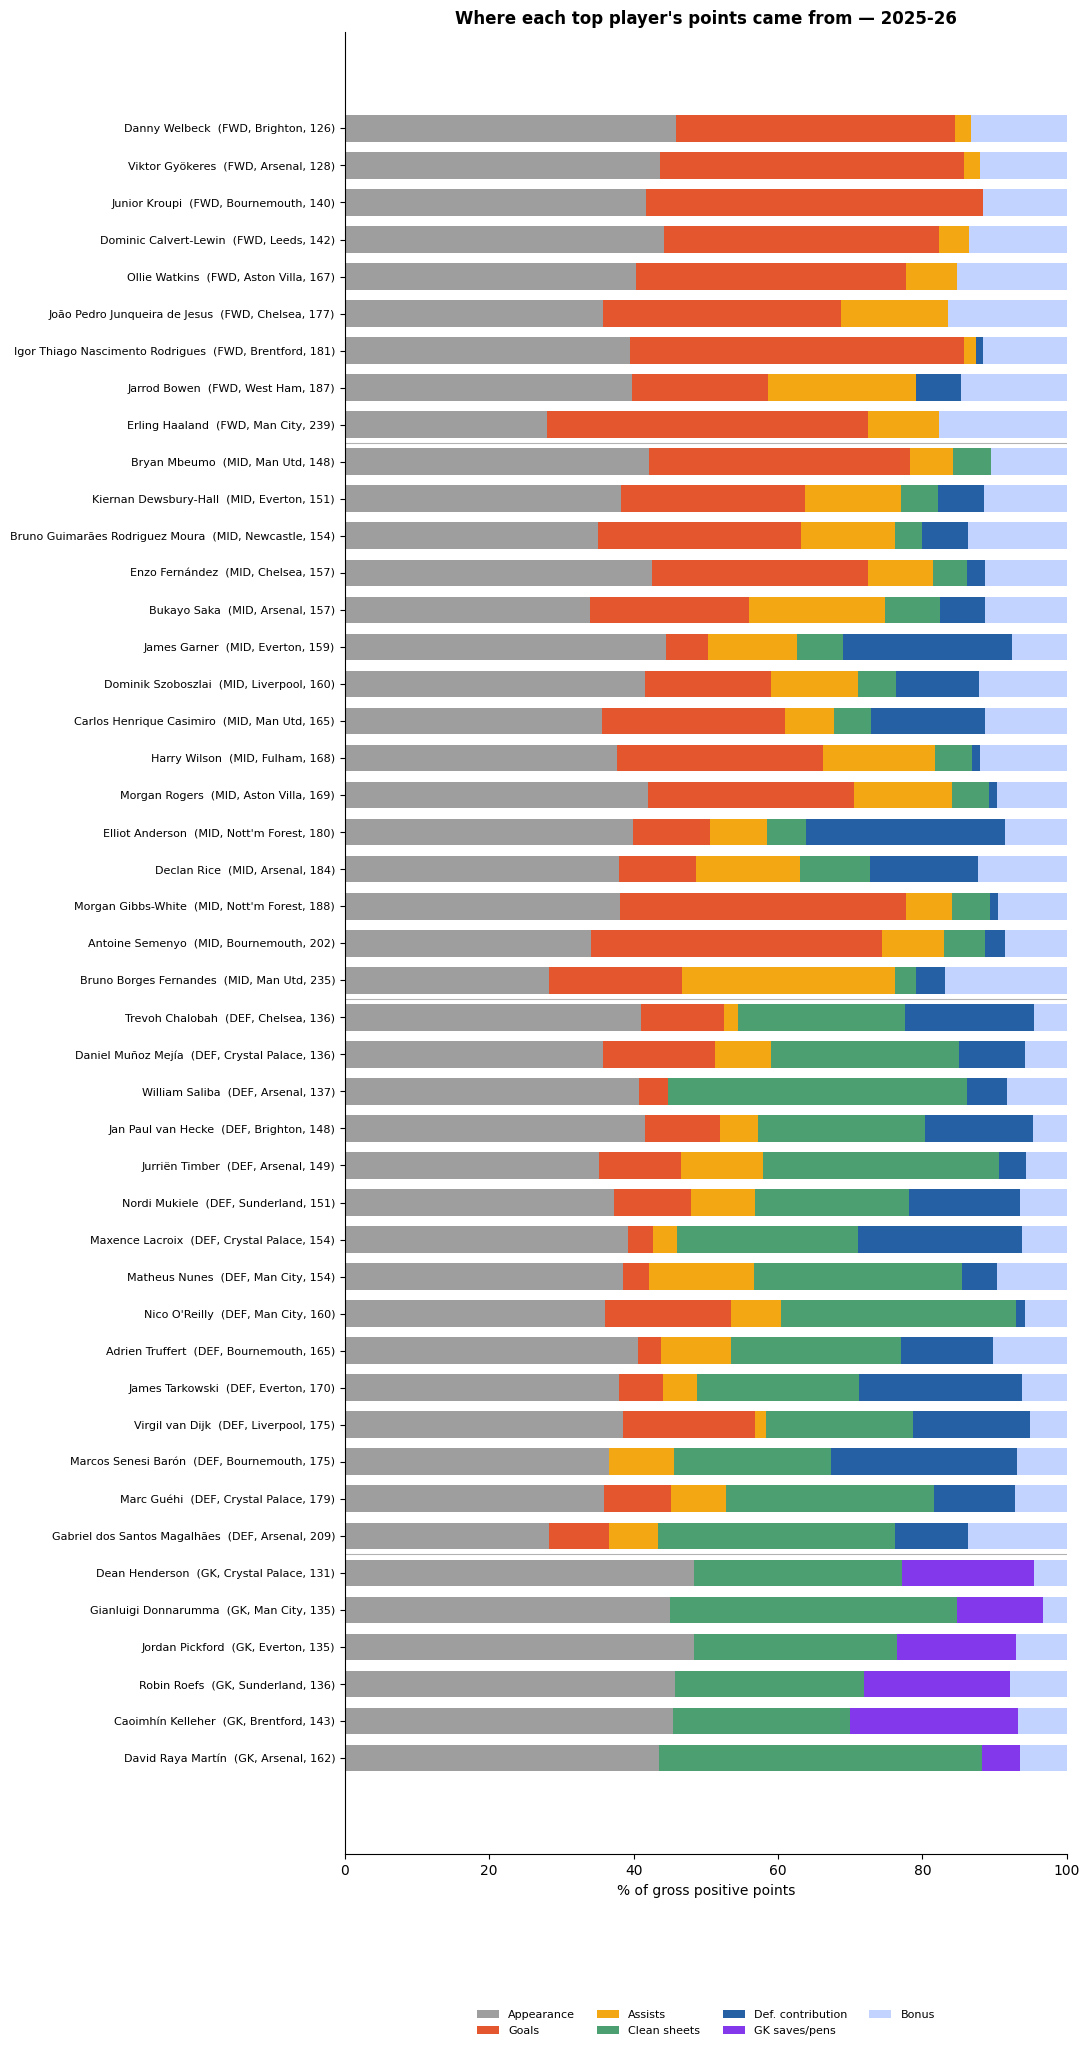

In [26]:
COLORS = {
    "appearance": "#9e9e9e", "goals": "#e4572e", "assists": "#f3a712",
    "clean_sheets": "#4c9f70", "def_contrib": "#2660a4", "gk_pts": "#8338ec",
    "bonus": "#c1d3fe"}
LABELS = {"appearance": "Appearance", "goals": "Goals", "assists": "Assists",
          "clean_sheets": "Clean sheets", "def_contrib": "Def. contribution",
          "gk_pts": "GK saves/pens", "bonus": "Bonus"}

d = uni.copy()
shares = d[POS_BUCKETS].div(d["gross_pos"], axis=0) * 100
y = np.arange(len(d))[::-1]   # top of chart = first row

fig, ax = plt.subplots(figsize=(11, 0.42 * len(d) + 1.5))
left = np.zeros(len(d))
for b in POS_BUCKETS:
    ax.barh(y, shares[b], left=left, color=COLORS[b], label=LABELS[b], height=0.72)
    left += shares[b].values

ax.set_yticks(y)
ax.set_yticklabels([f"{n}  ({p}, {t}, {int(pt)})"
                    for n, p, t, pt in zip(d["name"], d["position"], d["team"], d["total_points"])],
                   fontsize=8)
ax.set_xlim(0, 100); ax.set_xlabel("% of gross positive points")
ax.set_title(f"Where each top player's points came from — {SEASON}", fontsize=12, weight="bold")

# position dividers
bounds = np.cumsum([TOP_PER_POS[p] for p in ["GK", "DEF", "MID", "FWD"]])[:-1]
for b in bounds:
    ax.axhline(len(d) - b - 0.5, color="black", lw=0.8, alpha=0.3)

ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.06 - 0.9/len(d)), fontsize=8, frameon=False)
ax.invert_yaxis(); ax.set_yticks(y); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Heatmap — the same shares as a grid

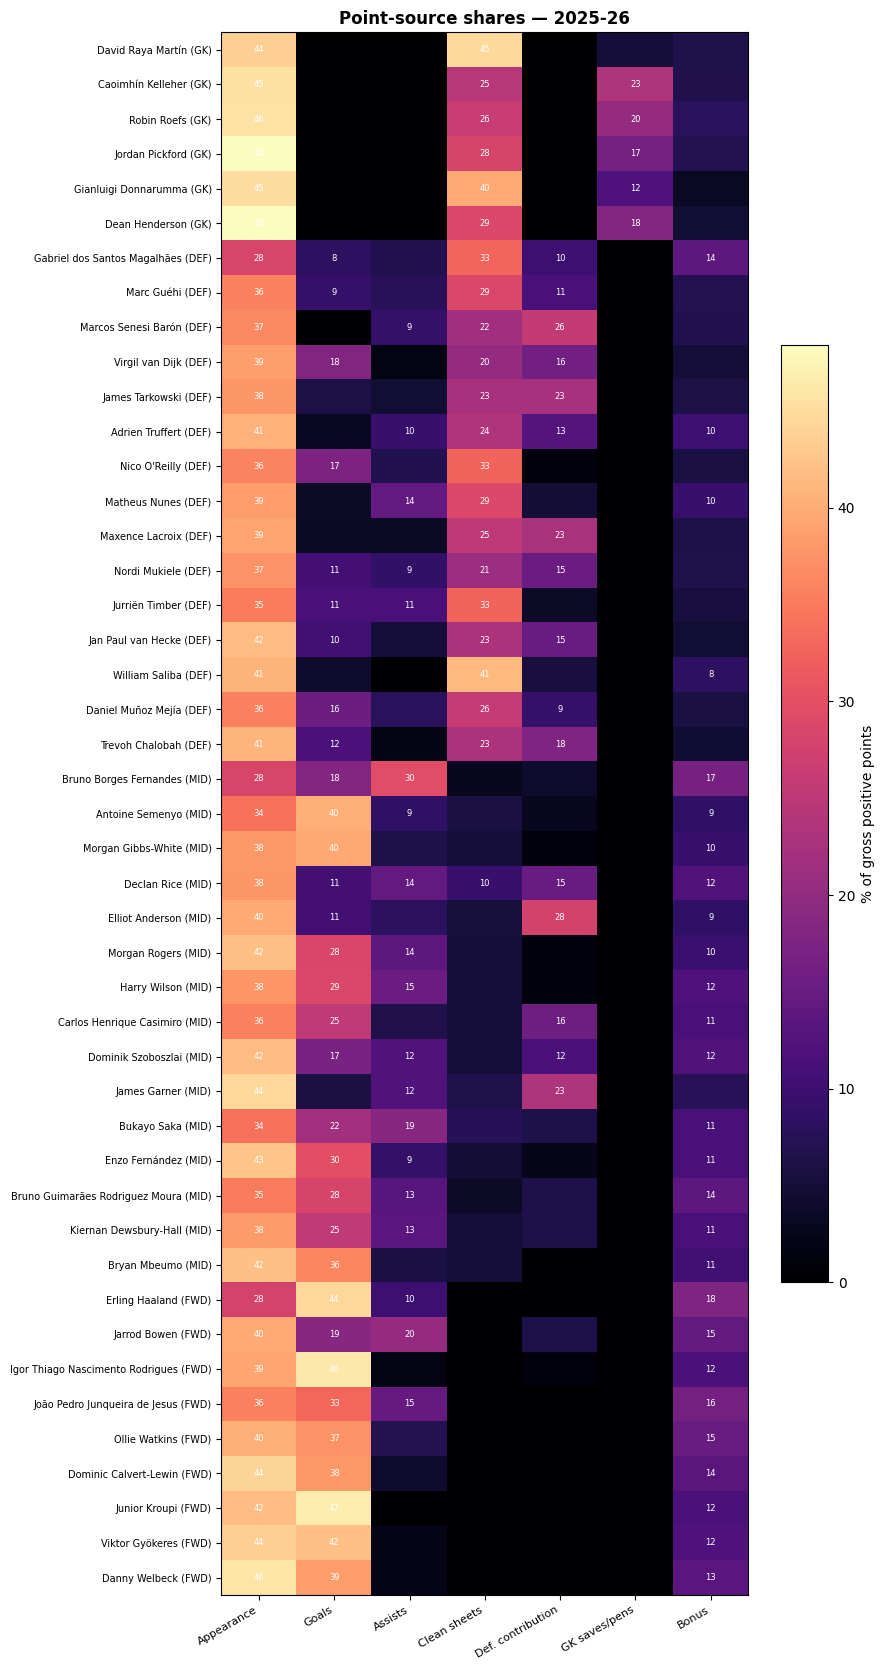

In [27]:
fig, ax = plt.subplots(figsize=(9, 0.34 * len(d) + 1.5))
M = shares[POS_BUCKETS].values
im = ax.imshow(M, aspect="auto", cmap="magma")
ax.set_xticks(range(len(POS_BUCKETS)))
ax.set_xticklabels([LABELS[b] for b in POS_BUCKETS], rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(d)))
ax.set_yticklabels([f"{n} ({p})" for n, p in zip(d["name"], d["position"])], fontsize=7)
for i in range(len(d)):
    for j in range(len(POS_BUCKETS)):
        if M[i, j] >= 8:
            ax.text(j, i, f"{M[i, j]:.0f}", ha="center", va="center",
                    color="white" if M[i, j] < 55 else "black", fontsize=6)
fig.colorbar(im, ax=ax, label="% of gross positive points", shrink=0.6)
ax.set_title(f"Point-source shares — {SEASON}", fontsize=12, weight="bold")
plt.tight_layout(); plt.show()

## Explosive vs grinder — attacking share vs floor share

- **Attacking share** = goals + assists (matchup-sensitive, boom-or-bust).
- **Floor share** = appearance + defensive contribution + clean sheets (near-guaranteed).

Top-left = grinders (high floor, low attacking); bottom-right = explosive attackers. This is the natural bridge to [#05 Fixture-Proof Players](../05-fixture-proof/): a high-floor player *should* be more fixture-proof.

First all positions together for the overview, then **one panel per position** (shared axes) so every name is readable.

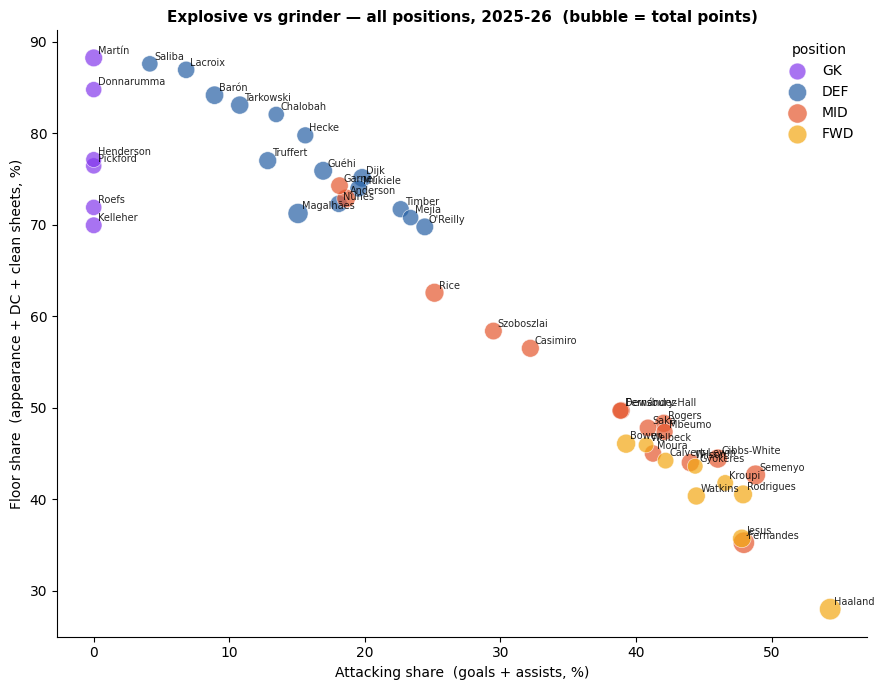

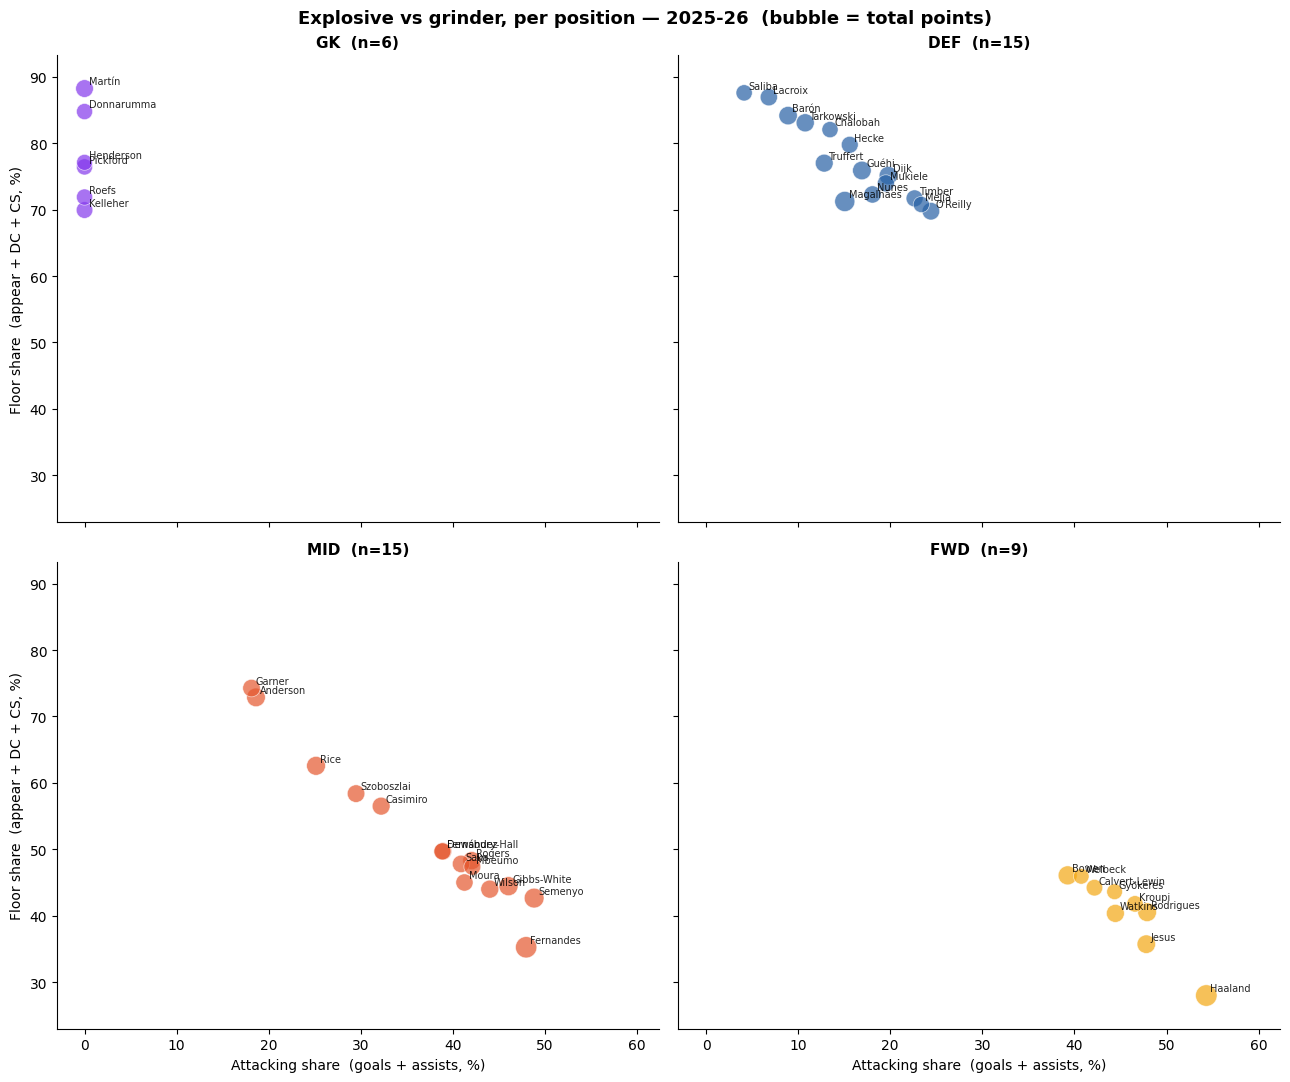

In [28]:
d["attack_share"] = shares["goals"] + shares["assists"]
d["floor_share"] = shares["appearance"] + shares["def_contrib"] + shares["clean_sheets"]
POS_COLOR = {"GK": "#8338ec", "DEF": "#2660a4", "MID": "#e4572e", "FWD": "#f3a712"}
POS_ORDER = ["GK", "DEF", "MID", "FWD"]

def scatter(ax, sub, title, annotate_all=True):
    for p in POS_ORDER:
        s = sub[sub["position"] == p]
        if len(s):
            ax.scatter(s["attack_share"], s["floor_share"], s=s["total_points"],
                       color=POS_COLOR[p], alpha=0.7, label=p, edgecolor="white", linewidth=0.5)
    for _, r in sub.iterrows():
        ax.annotate(r["name"].split()[-1], (r["attack_share"], r["floor_share"]),
                    fontsize=7, alpha=0.85, xytext=(3, 3), textcoords="offset points")
    ax.set_title(title, fontsize=11, weight="bold")
    ax.spines[["top", "right"]].set_visible(False)

# --- 1) All positions together (the overview) ---
fig, ax = plt.subplots(figsize=(9, 7))
scatter(ax, d, f"Explosive vs grinder — all positions, {SEASON}  (bubble = total points)")
ax.set_xlabel("Attacking share  (goals + assists, %)")
ax.set_ylabel("Floor share  (appearance + DC + clean sheets, %)")
ax.legend(title="position", frameon=False)
plt.tight_layout(); plt.show()

# --- 2) One panel per position (room for every name), shared axes for comparability ---
xlim = (-3, d["attack_share"].max() + 8)
ylim = (d["floor_share"].min() - 5, d["floor_share"].max() + 5)
fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharex=True, sharey=True)
for ax, p in zip(axes.ravel(), POS_ORDER):
    sub = d[d["position"] == p]
    scatter(ax, sub, f"{p}  (n={len(sub)})")
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    if ax in axes[:, 0]:
        ax.set_ylabel("Floor share  (appear + DC + CS, %)")
    if ax in axes[-1, :]:
        ax.set_xlabel("Attacking share  (goals + assists, %)")
fig.suptitle(f"Explosive vs grinder, per position — {SEASON}  (bubble = total points)",
             fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

## Takeaways

- **The decomposition is lossless.** Every one of ~29,700 player-GW rows reconstructs its exact `total_points` from raw counts + the 2025/26 rules, so every share below is auditable, not approximate.
- **Same total, different asset.** The stacked bars separate boom-or-bust attackers (attacking share dominant) from grinders whose floor is appearance + bonus + the new defensive-contribution points.
- **Defensive contribution is a real, new slice** — its size per player is the first clean read on who actually banks those points.
- **Bridge to #05:** high floor-share players are the natural fixture-proof candidates; the explosive/grinder scatter is where to start that cross-read.

*Read the table + money shot together: totals tell you the hook, the split tells you how repeatable it is.*